In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv('/content/train.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month

df['Day'] = df['Order Date'].dt.day

In [5]:
data = df[
    [
        'Year',
        'Month',
        'Day',
        'Category',
        'Sub-Category',
        'Region',
        'Segment',
        'Sales'
    ]
]

In [6]:
encoder = LabelEncoder()

categorical_cols = [
    'Category',
    'Sub-Category',
    'Region',
    'Segment'
]

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

data.head()

/tmp/ipykernel_26860/2583446566.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = encoder.fit_transform(data[col])
/tmp/ipykernel_26860/2583446566.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = encoder.fit_transform(data[col])
/tmp/ipykernel_26860/2583446566.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

,Year,Month,Day,Category,Sub-Category,Region,Segment,Sales
0,2017,11,8,0,4,2,0,261.9600
1,2017,11,8,0,5,2,0,731.9400
2,2017,6,12,1,10,3,1,14.6200
3,2016,10,11,0,16,2,0,957.5775
4,2016,10,11,1,14,2,0,22.3680


In [7]:
X = data.drop('Sales', axis=1)

y = data['Sales']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [10]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", round(mae,2))

print("RMSE:", round(rmse,2))

print("R² Score:", round(r2,2))

MAE: 270.74
RMSE: 811.69
R² Score: 0.01


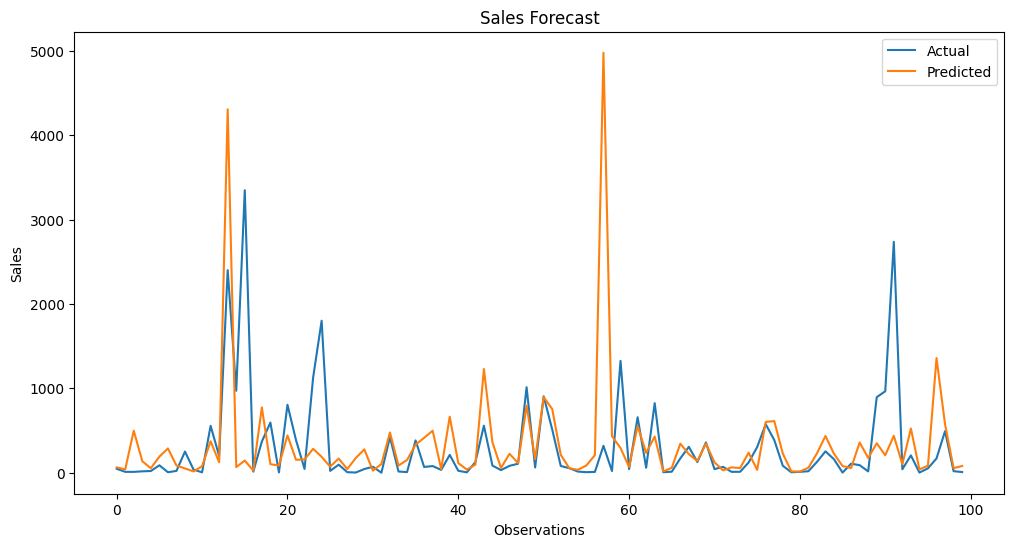

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    predictions[:100],
    label='Predicted'
)

plt.title('Sales Forecast')

plt.xlabel('Observations')

plt.ylabel('Sales')

plt.legend()

plt.show()


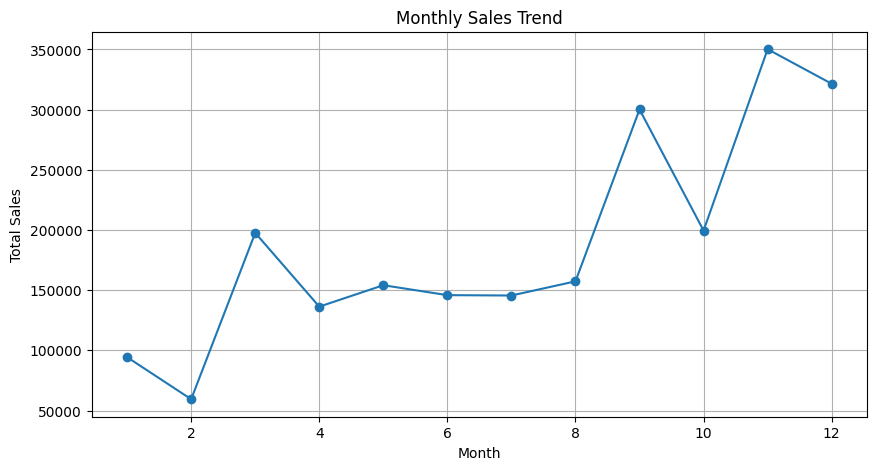

In [12]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')

plt.xlabel('Month')

plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

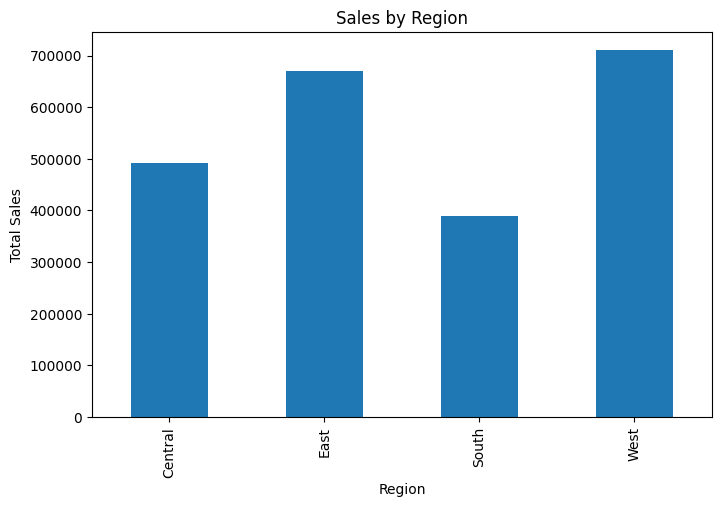

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')

plt.xlabel('Region')

plt.ylabel('Total Sales')

plt.show()

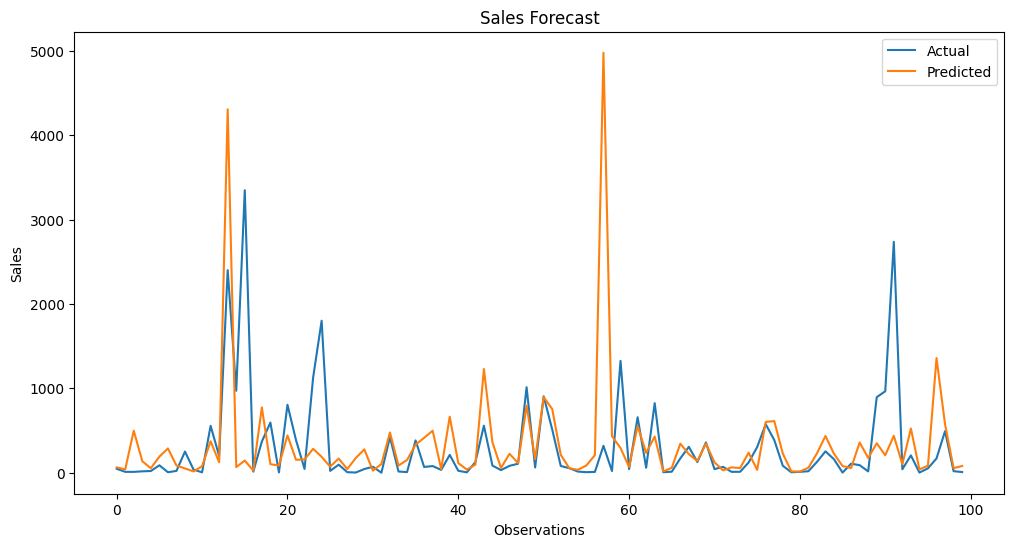

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    predictions[:100],
    label='Predicted'
)

plt.title('Sales Forecast')

plt.xlabel('Observations')

plt.ylabel('Sales')

plt.legend()

plt.savefig('forecast.png')

plt.show()

## Business Insights

1. Sales vary across months.

2. Certain regions generate more revenue.

3. Product categories influence overall sales.

4. Sales forecasting can help inventory planning.

5. Businesses can use these insights to optimize operations.